In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bank.csv', sep=';')

df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [2]:
shape_of_data = df.shape

shape_of_data



(4521, 17)

In [3]:
columns_data = df.columns

columns_data

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [4]:
type_data = df.dtypes

type_data

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

In [5]:
df_number_columns = df[['age','balance', 'previous', 'day', 'month', 'duration', 'campaign', 'pdays']]
df_catgory_columns = df[['job', 'education', 'contact', 'poutcome', 'marital']]
df_binry_columns = df[['default', 'housing', 'loan', 'y']]

In [6]:
null_in_df1 = df.isnull().sum()

null_in_df1

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
null = df == 'unknown'
null_in_df2 = null.sum()
print(null_in_df2)

age             0
job            38
marital         0
education     187
default         0
balance         0
housing         0
loan            0
contact      1324
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     3705
y               0
dtype: int64


In [8]:
percent_of_null = null_in_df2 / len(df)*  100

percent_of_null

age           0.000000
job           0.840522
marital       0.000000
education     4.136253
default       0.000000
balance       0.000000
housing       0.000000
loan          0.000000
contact      29.285556
day           0.000000
month         0.000000
duration      0.000000
campaign      0.000000
pdays         0.000000
previous      0.000000
poutcome     81.950896
y             0.000000
dtype: float64

In [9]:
duplicated_is_in_data = df[df.duplicated()]

duplicated_is_in_data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y


y
no     4000
yes     521
Name: count, dtype: int64

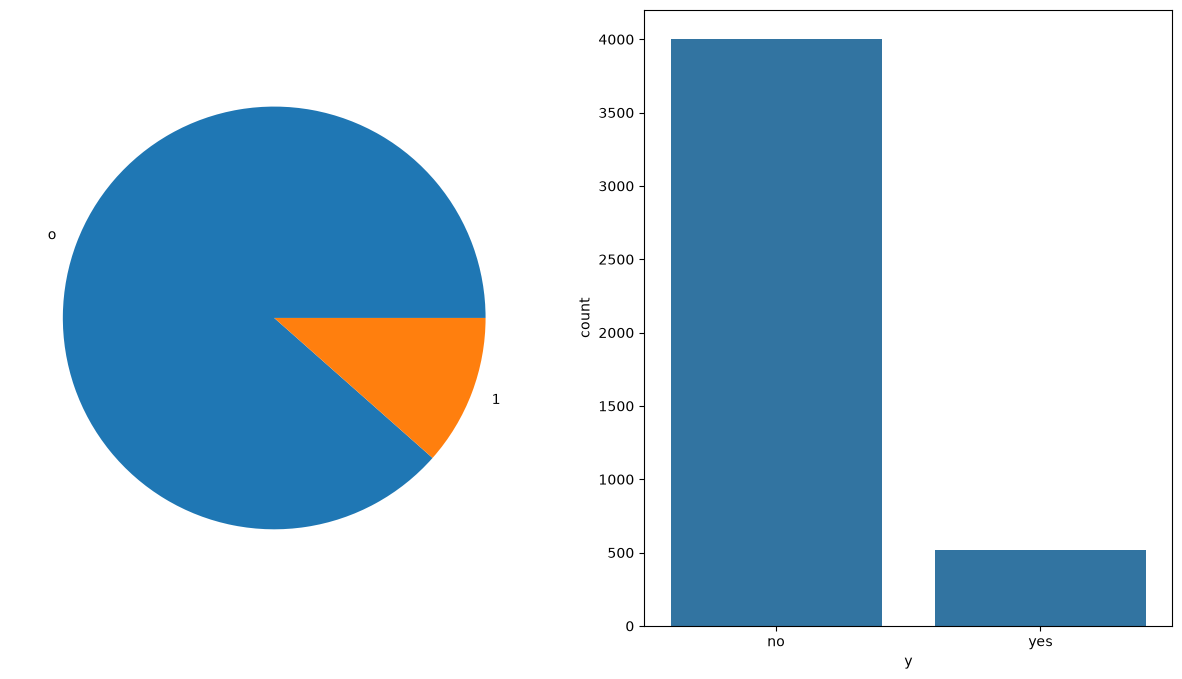

In [10]:
y_count = df['y'].value_counts()

fig, axes =plt.subplots(1, 2 , figsize=(15, 8))

axes[0].pie(y_count, labels=['o', '1'] )

sns.countplot(x='y', data=df)

y_count

y
no     88.476001
yes    11.523999
Name: count, dtype: float64
7.677543186180422


<Axes: xlabel='count'>

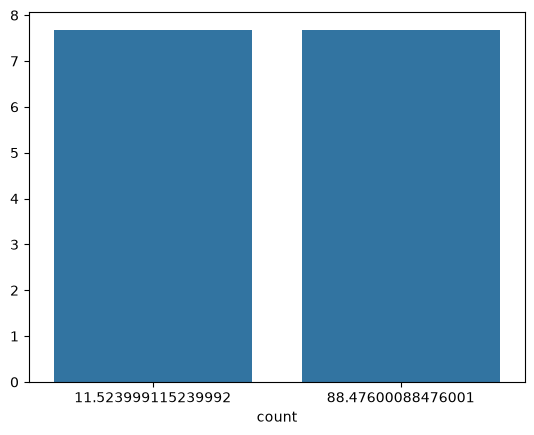

In [11]:
percent_y = (y_count / len(df)) * 100
ratio_y = float(y_count.max() / y_count.min())
print(percent_y)
print(ratio_y )
sns.barplot(x=percent_y, y=ratio_y)

In [12]:
describe_data = df.describe()

describe_data

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [13]:
data_Features_with_mean_and_median = df[['age','balance', 'previous', 'day', 'duration', 'campaign', 'pdays']].agg(['mean', 'median'])
data_Features_with_mod = df[['age','balance', 'previous', 'day', 'duration', 'campaign', 'pdays']].mode(0)
print(data_Features_with_mean_and_median)
print(data_Features_with_mod)

              age      balance  previous        day    duration  campaign  \
mean    41.170095  1422.657819  0.542579  15.915284  263.961292   2.79363   
median  39.000000   444.000000  0.000000  16.000000  185.000000   2.00000   

            pdays  
mean    39.766645  
median  -1.000000  
   age  balance  previous  day  duration  campaign  pdays
0   34        0         0   20       123         1     -1


In [14]:
data_Features_with_var_and_std = df[['age','balance', 'previous', 'day', 'duration', 'campaign', 'pdays']].agg(['var', 'std'])

print(data_Features_with_var_and_std)


            age       balance  previous        day      duration  campaign  \
var  111.856238  9.057922e+06  2.868153  68.024016  67525.469519  9.670897   
std   10.576211  3.009638e+03  1.693562   8.247667    259.856633  3.109807   

            pdays  
var  10024.239560  
std    100.121124  


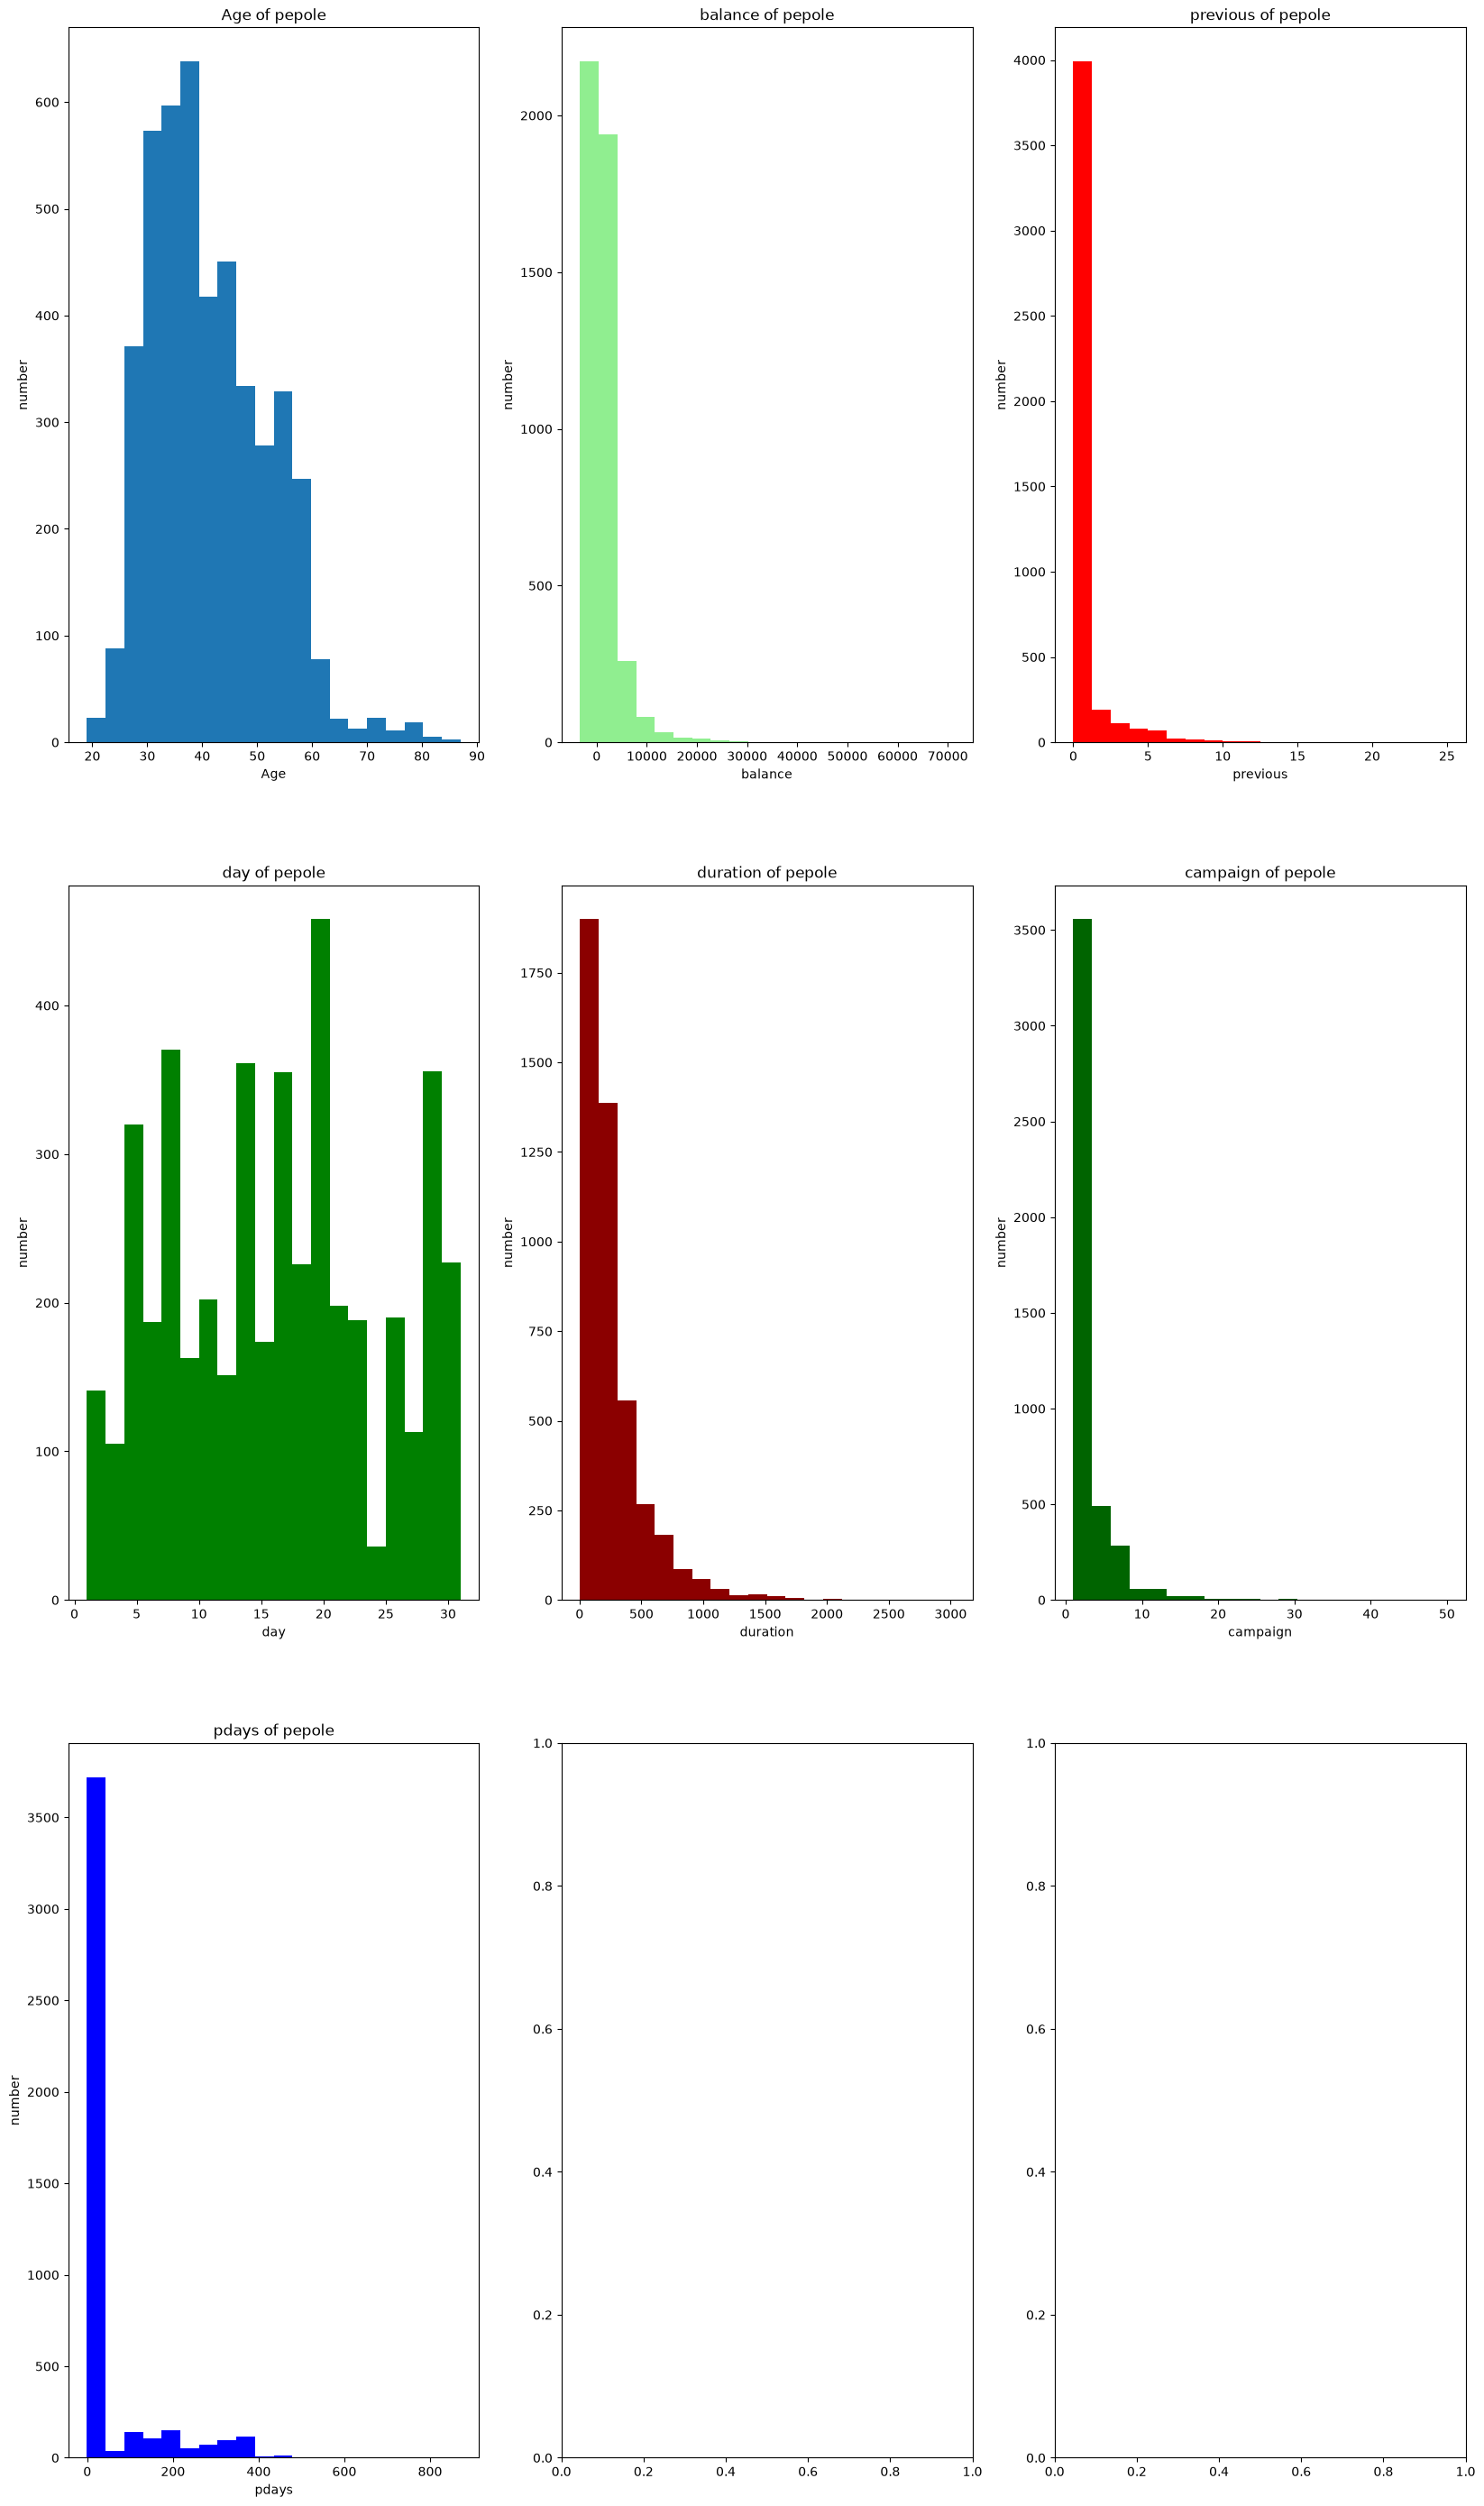

In [15]:
fig, axes = plt.subplots(3, 3 , figsize=(20, 35))
axes[0,0].hist( df['age'], bins=20)
axes[0,0].set_title('Age of pepole')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('number')

axes[0,1].hist(df['balance'], bins=20 , color='lightgreen')
axes[0,1].set_title('balance of pepole')
axes[0,1].set_xlabel('balance')
axes[0,1].set_ylabel('number')

axes[0,2].hist(df['previous'], bins=20 , color='red')
axes[0,2].set_title('previous of pepole')
axes[0,2].set_xlabel('previous')
axes[0,2].set_ylabel('number')

axes[1,0].hist(df['day'], bins=20 , color='green')
axes[1,0].set_title('day of pepole')
axes[1,0].set_xlabel('day')
axes[1,0].set_ylabel('number')

axes[1,1].hist(df['duration'], bins=20 , color='darkred')
axes[1,1].set_title('duration of pepole')
axes[1,1].set_xlabel('duration')
axes[1,1].set_ylabel('number')

axes[1,2].hist(df['campaign'], bins=20 , color='darkgreen')
axes[1,2].set_title('campaign of pepole')
axes[1,2].set_xlabel('campaign')
axes[1,2].set_ylabel('number')

axes[2,0].hist(df['pdays'], bins=20 , color='blue')
axes[2,0].set_title('pdays of pepole')
axes[2,0].set_xlabel('pdays')
axes[2,0].set_ylabel('number')


plt.show()

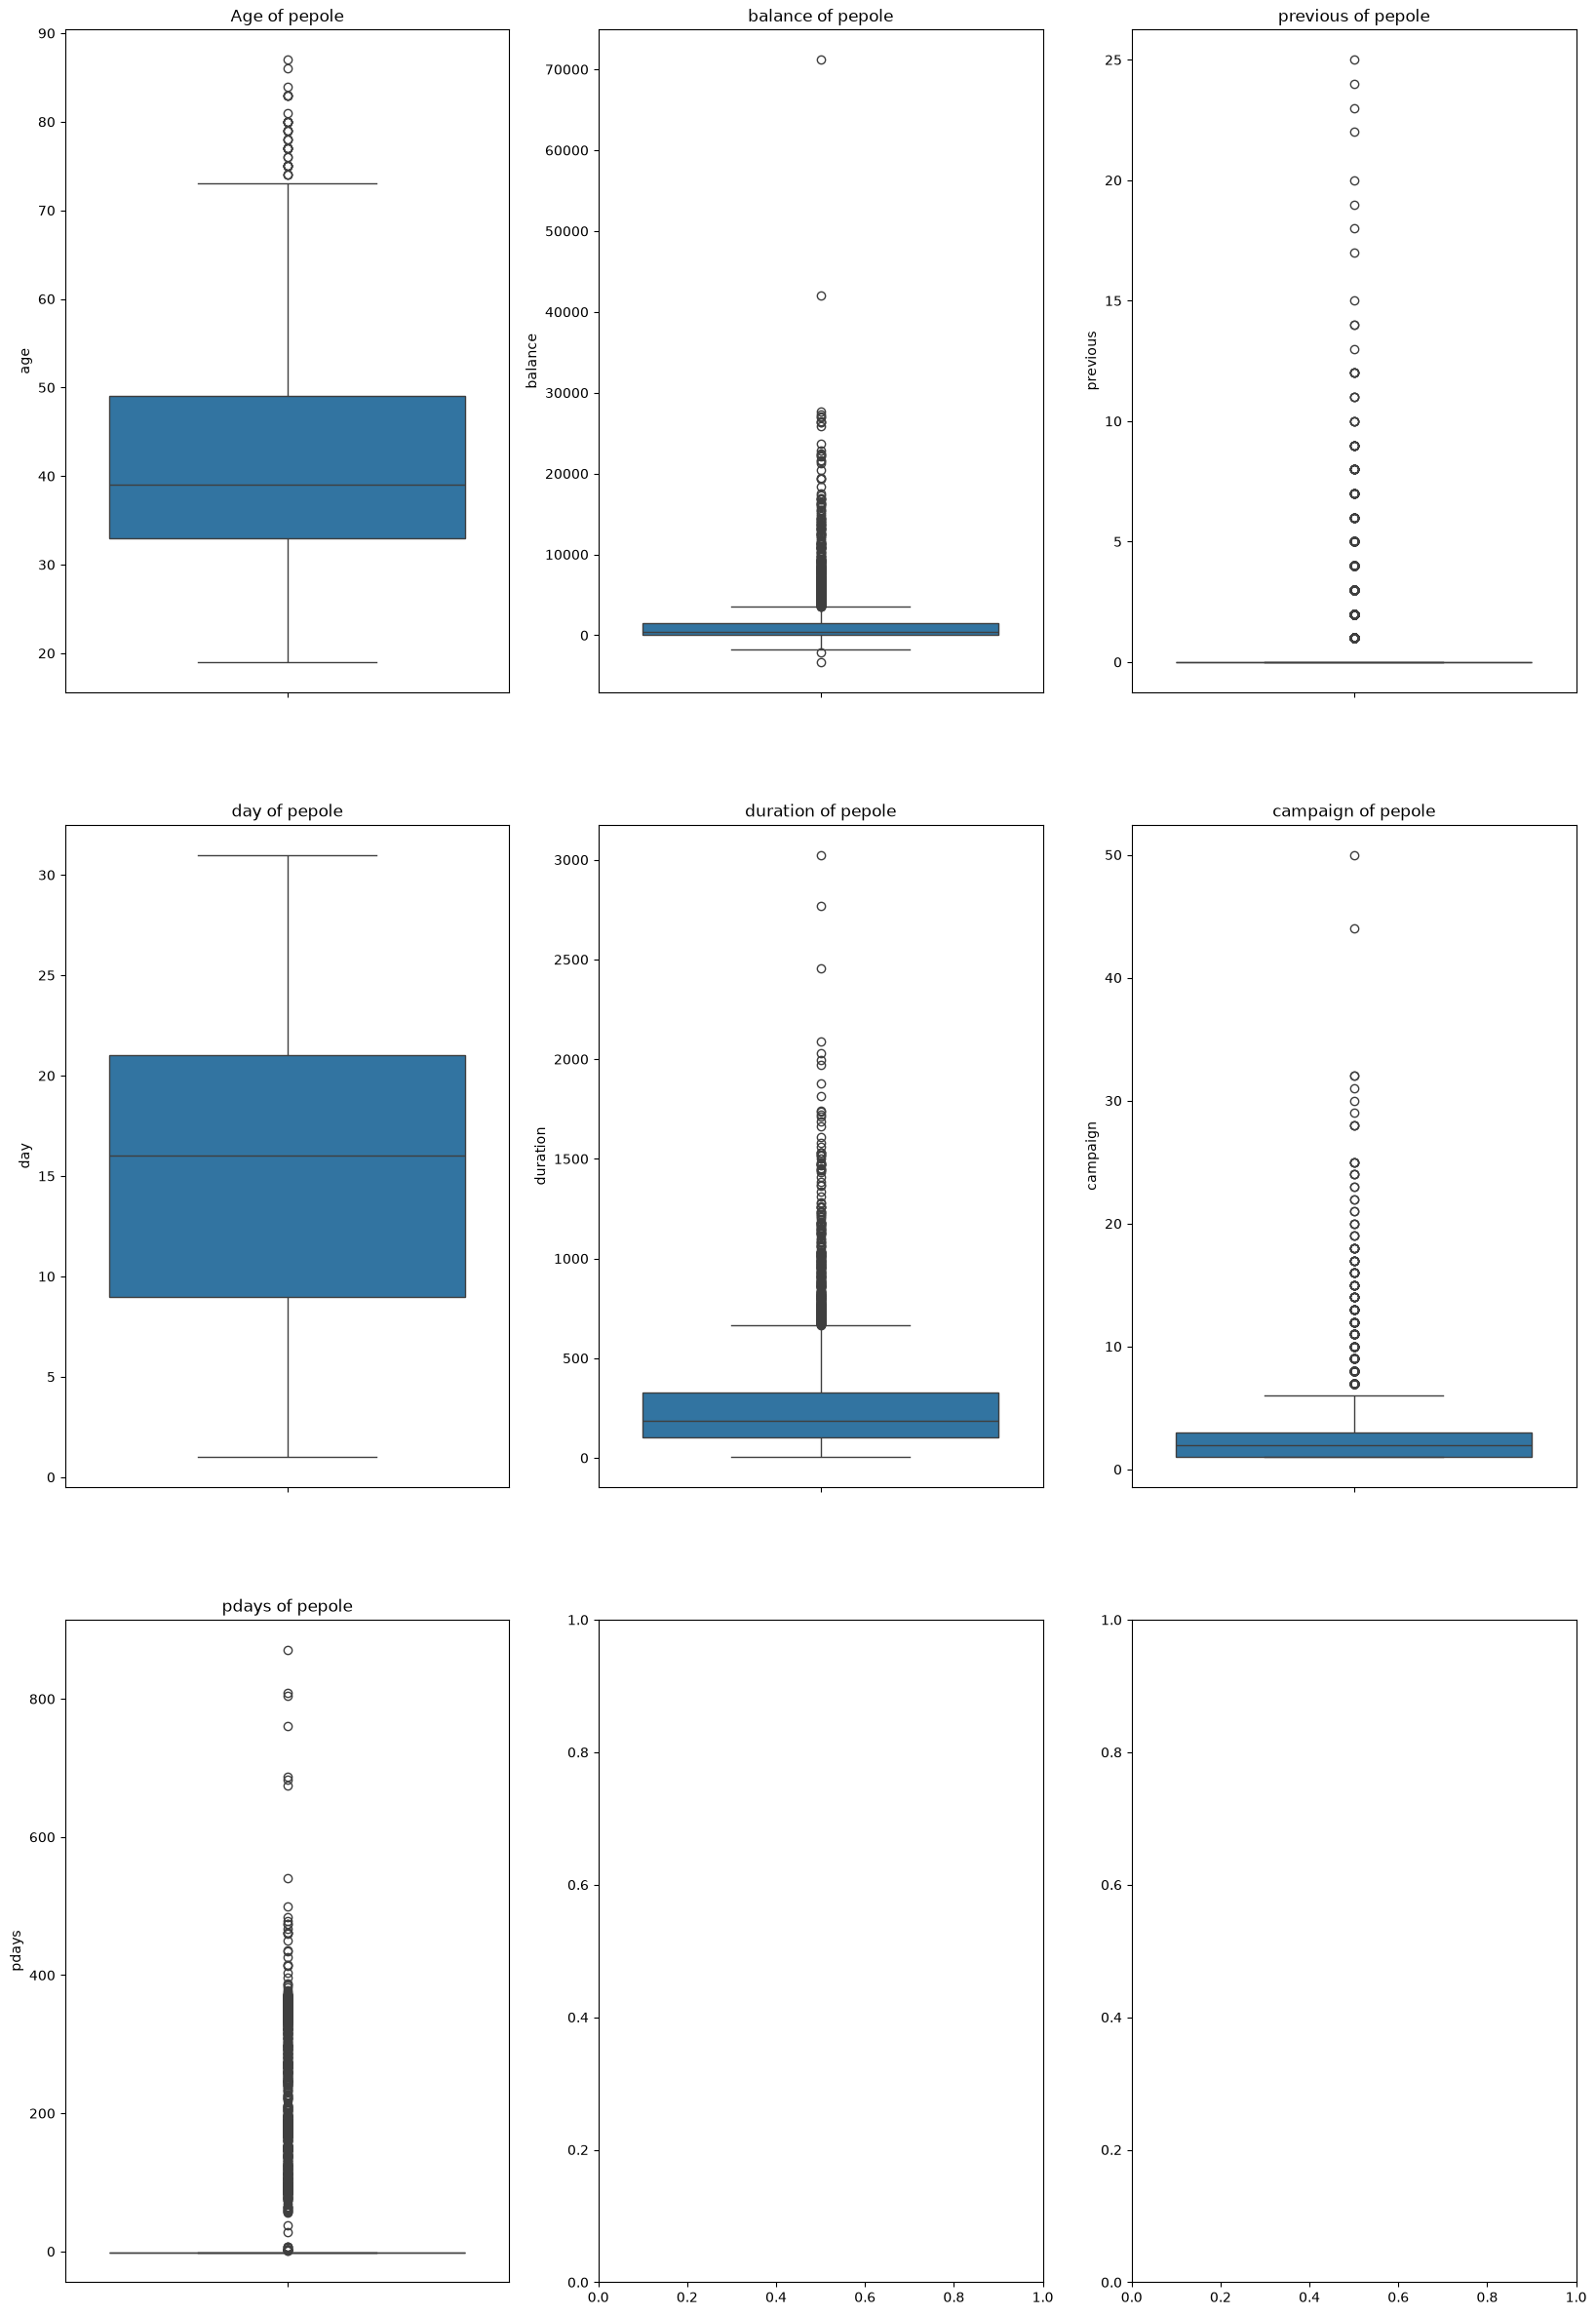

In [16]:
fig, axes = plt.subplots(3, 3 , figsize=(20, 30))

sns.boxplot(df['age'], ax = axes[0,0])
axes[0,0].set_title('Age of pepole')

sns.boxplot(df['balance'],ax = axes[0,1])
axes[0,1].set_title('balance of pepole')

sns.boxplot(df['previous'], ax = axes[0,2])
axes[0,2].set_title('previous of pepole')

sns.boxplot(df['day'], ax =  axes[1,0])
axes[1,0].set_title('day of pepole')

sns.boxplot(df['duration'], ax = axes[1,1])
axes[1,1].set_title('duration of pepole')

sns.boxplot(df['campaign'], ax = axes[1,2])
axes[1,2].set_title('campaign of pepole')

sns.boxplot(df['pdays'], ax = axes[2,0])
axes[2,0].set_title('pdays of pepole')

plt.show()

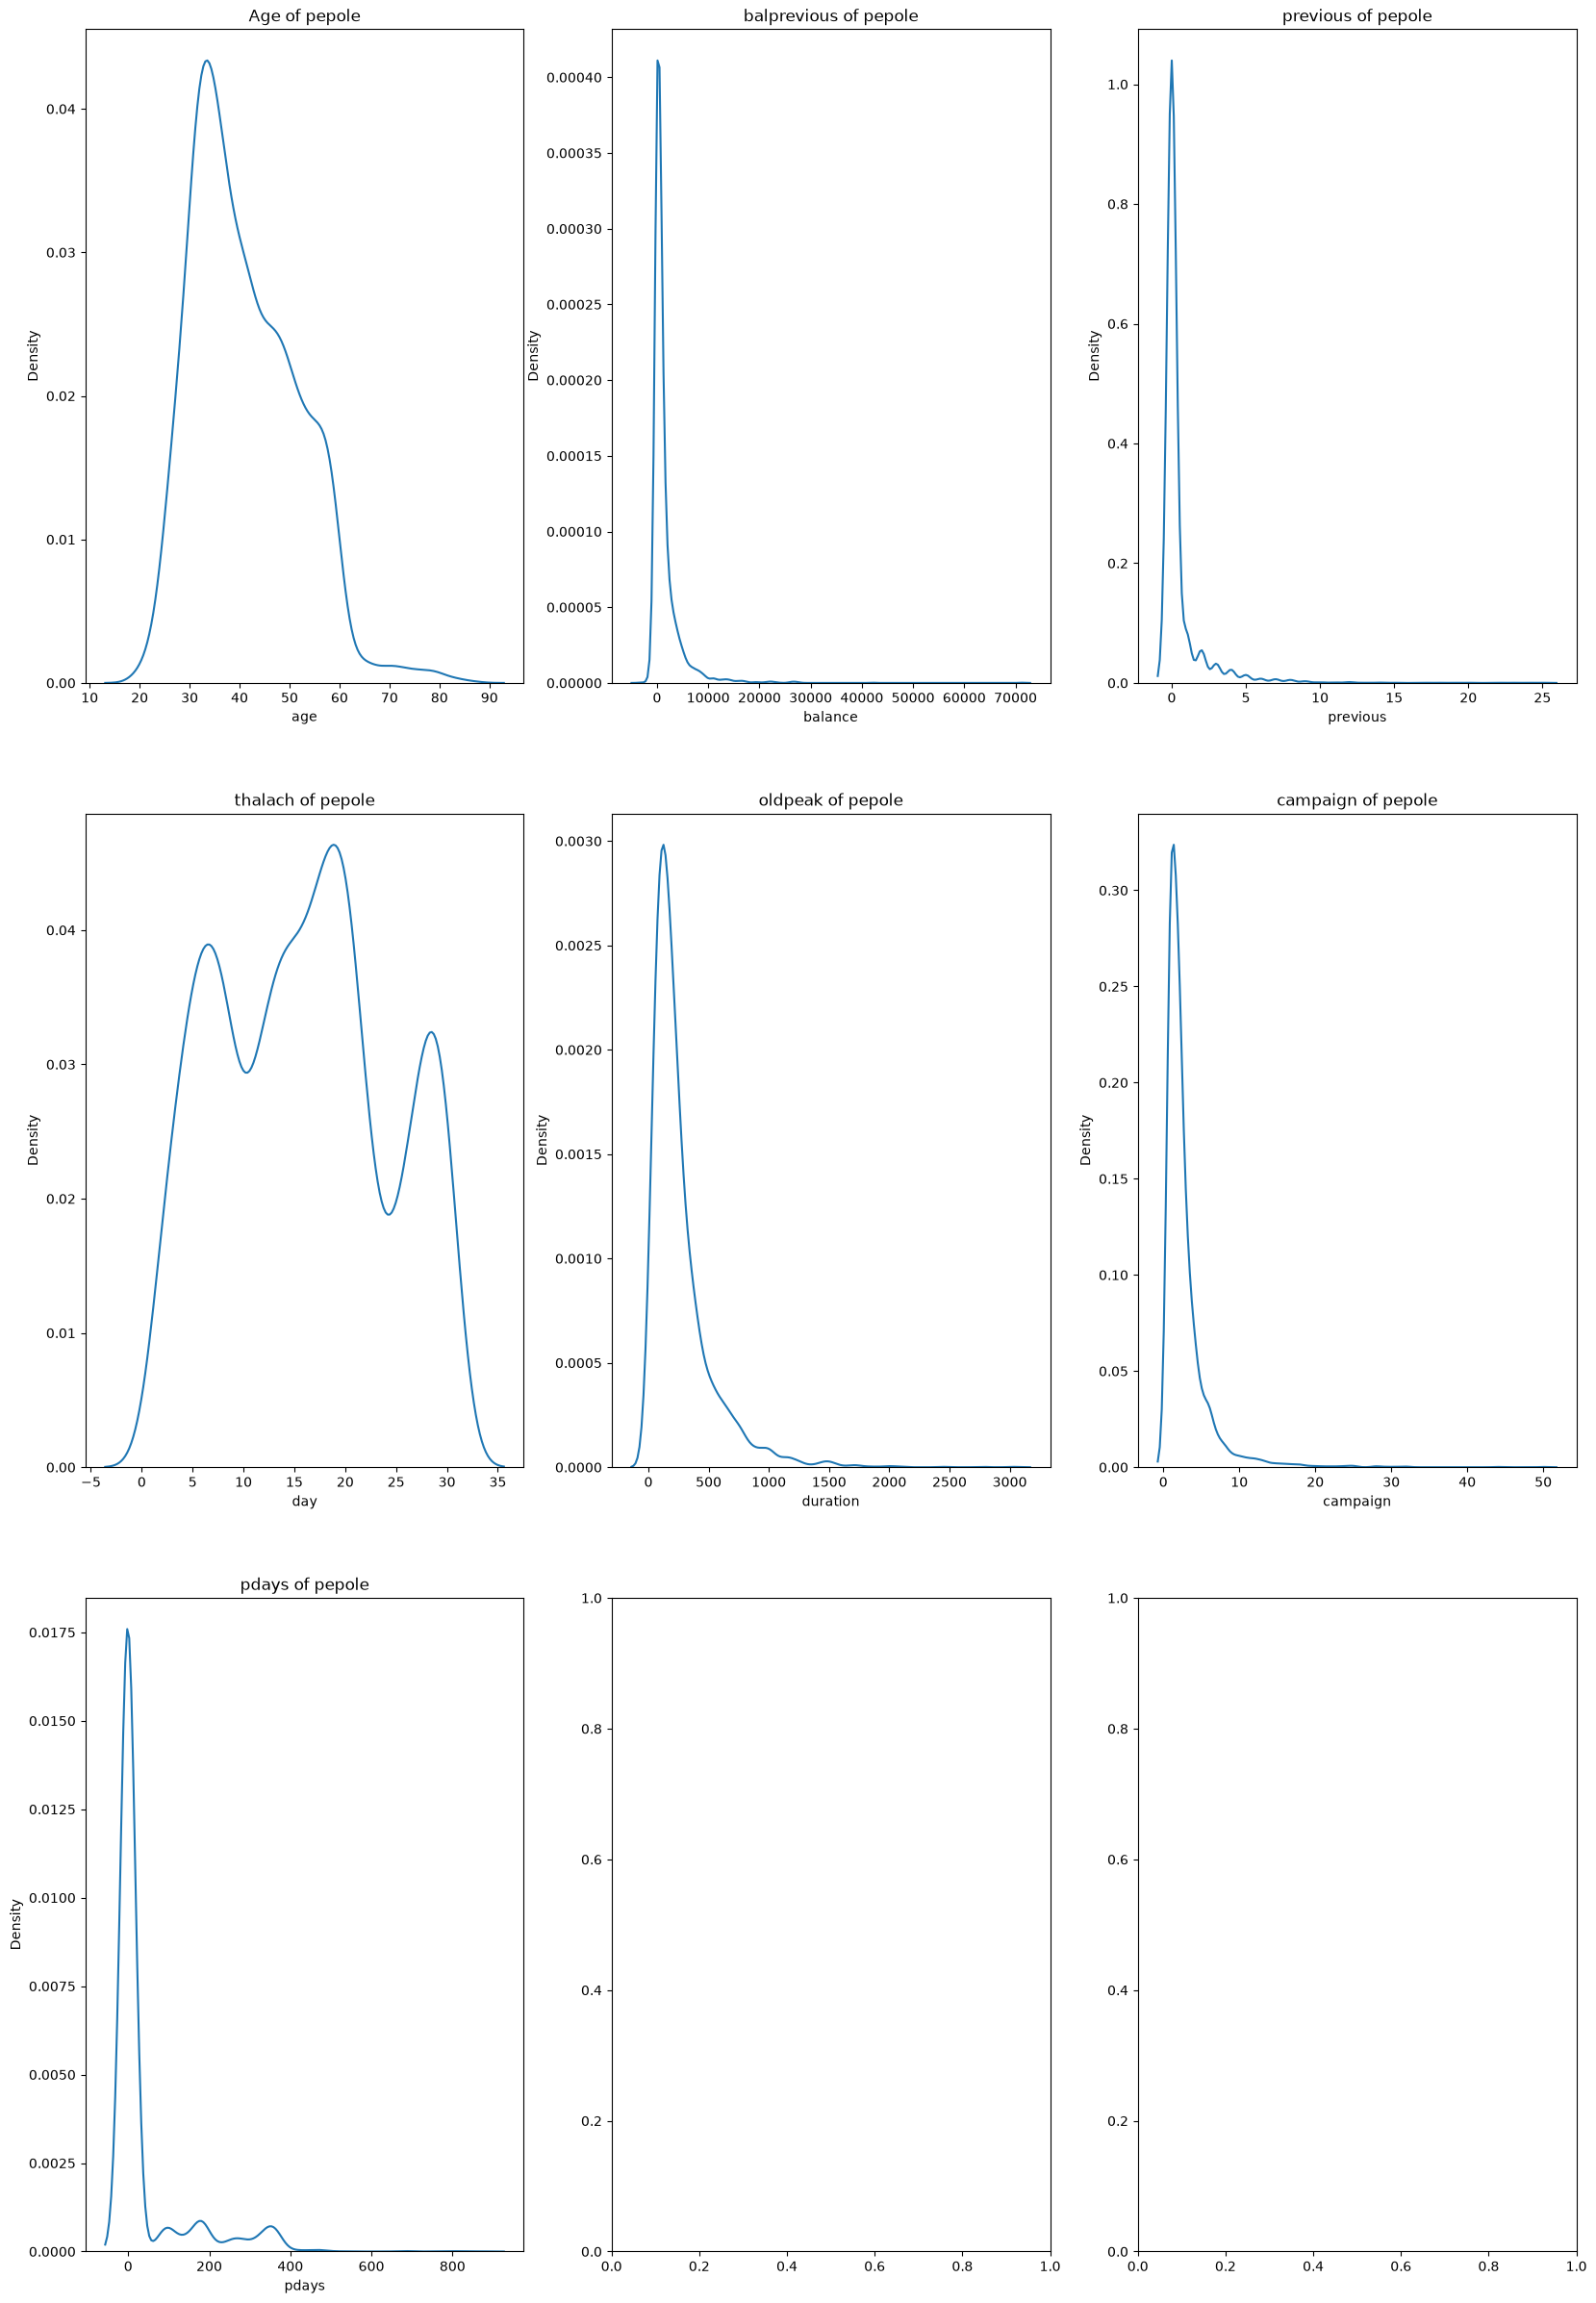

In [17]:
fig, axes = plt.subplots(3, 3 , figsize=(20, 30))

sns.kdeplot(df['age'], ax = axes[0,0])
axes[0,0].set_title('Age of pepole')

sns.kdeplot(df['balance'],ax = axes[0,1])
axes[0,1].set_title('balprevious of pepole')

sns.kdeplot(df['previous'], ax = axes[0,2])
axes[0,2].set_title('previous of pepole')

sns.kdeplot(df['day'], ax =  axes[1,0])
axes[1,0].set_title('thalach of pepole')

sns.kdeplot(df['duration'], ax = axes[1,1])
axes[1,1].set_title('oldpeak of pepole')

sns.kdeplot(df['campaign'], ax = axes[1,2])
axes[1,2].set_title('campaign of pepole')

sns.kdeplot(df['pdays'], ax = axes[2,0])
axes[2,0].set_title('pdays of pepole')

plt.show()

In [18]:
for columns in df_catgory_columns:
    print(df[columns].value_counts())

df_catgory_columns


job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64
education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64
contact
cellular     2896
unknown      1324
telephone     301
Name: count, dtype: int64
poutcome
unknown    3705
failure     490
other       197
success     129
Name: count, dtype: int64
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64


,job,education,contact,poutcome,marital
0,unemployed,primary,cellular,unknown,married
1,services,secondary,cellular,failure,married
2,management,tertiary,cellular,failure,single
3,management,tertiary,unknown,unknown,married
4,blue-collar,secondary,unknown,unknown,married
...,...,...,...,...,...
4516,services,secondary,cellular,unknown,married
4517,self-employed,tertiary,unknown,unknown,married
4518,technician,secondary,cellular,unknown,married
4519,blue-collar,secondary,cellular,other,married


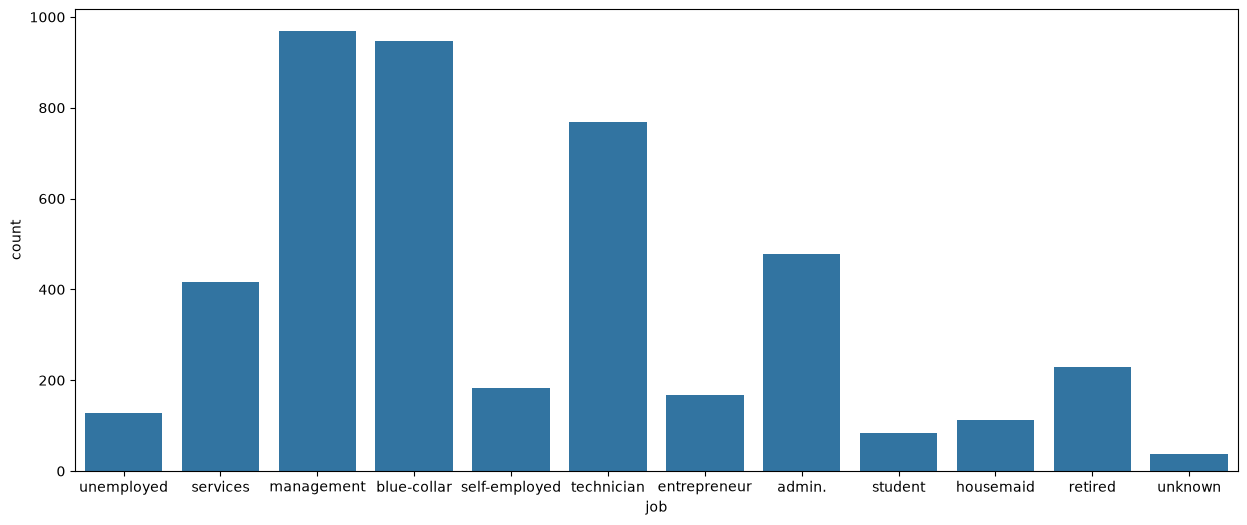

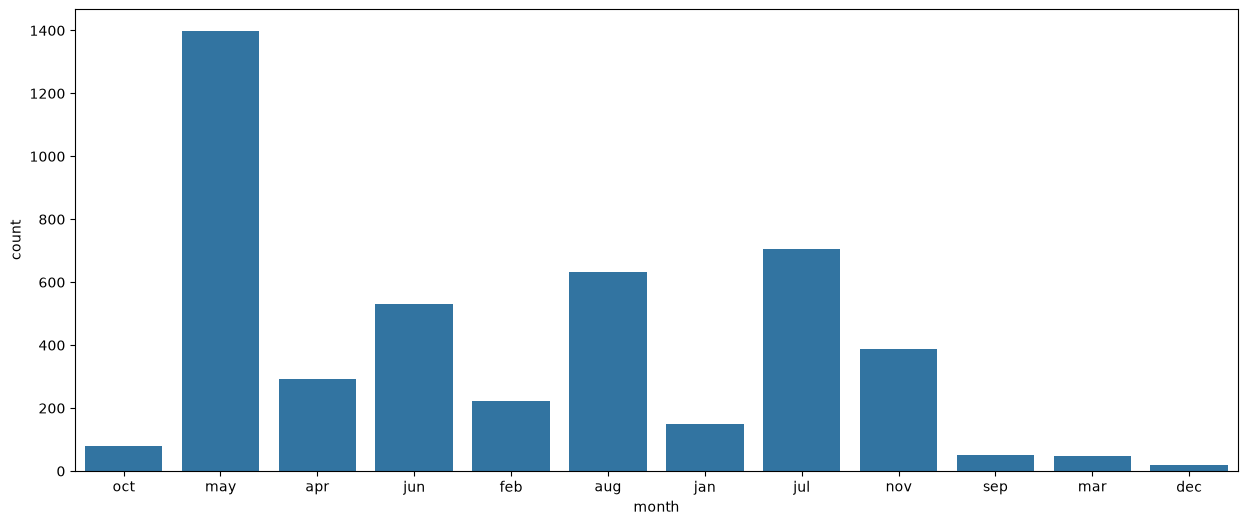

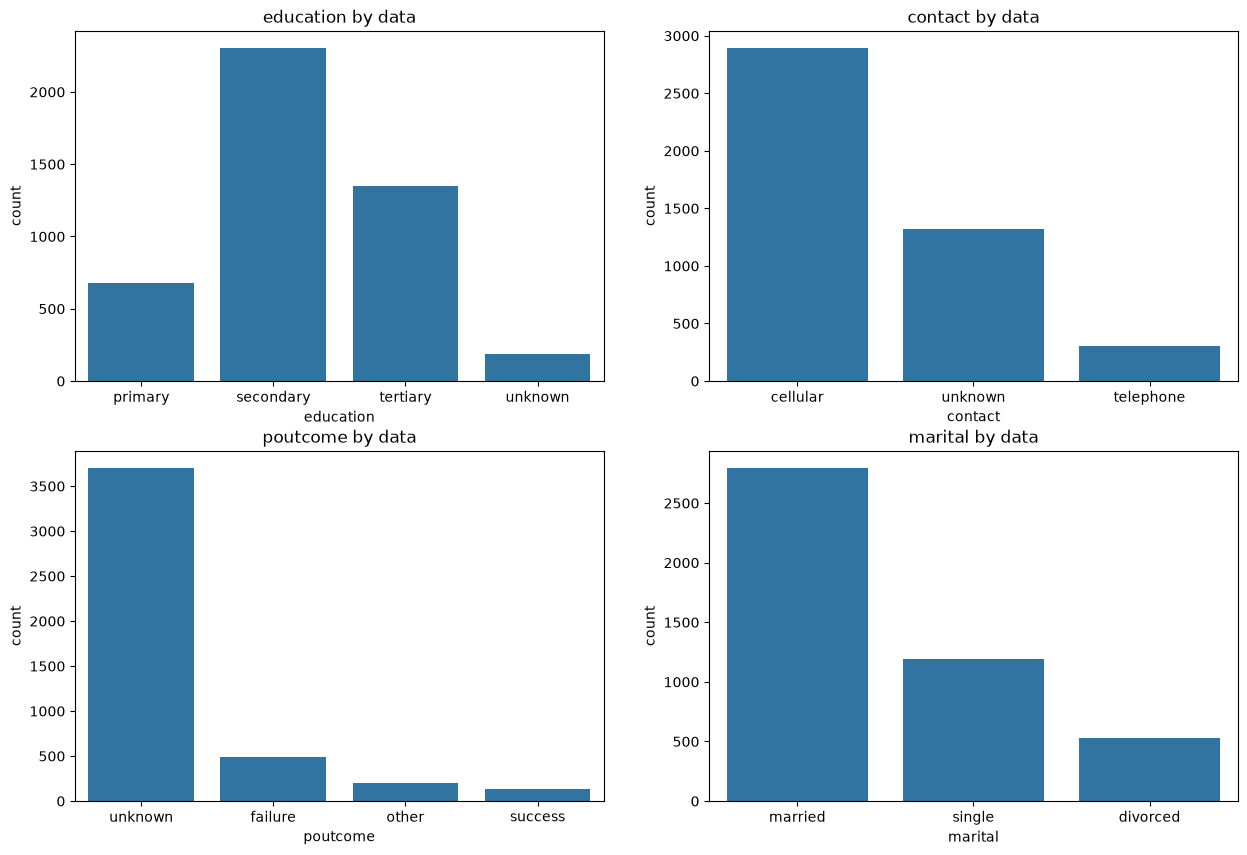

In [19]:
plt.figure(figsize=(15, 6))
sns.countplot(x='job', data=df)

plt.figure(figsize=(15, 6))
sns.countplot(x='month', data=df) 

fig, axes = plt.subplots(2, 2 , figsize=(15, 10))

sns.countplot(x='education', data=df, ax=axes[0,0])
axes[0,0].set_title('education by data')

sns.countplot(x='contact', data=df, ax=axes[0,1])
axes[0,1].set_title('contact by data')

sns.countplot(x='poutcome', data=df, ax=axes[1,0])
axes[1,0].set_title('poutcome by data')

sns.countplot(x='marital', data=df, ax=axes[1,1])
axes[1,1].set_title('marital by data')
'marital'

plt.show()

In [20]:
age_to_y = df.groupby('y')['age'].mean()
print(age_to_y)

y
no     40.998000
yes    42.491363
Name: age, dtype: float64


In [21]:
balance_to_y = df.groupby('y')['balance'].mean()
print(balance_to_y)

y
no     1403.211750
yes    1571.955854
Name: balance, dtype: float64


In [22]:
previous_to_y = df.groupby('y')['previous'].mean()
print(previous_to_y)

y
no     0.471250
yes    1.090211
Name: previous, dtype: float64


In [23]:
day_to_y = df.groupby('y')['day'].mean()
print(day_to_y)

y
no     15.948750
yes    15.658349
Name: day, dtype: float64


In [24]:
duration_to_y = df.groupby('y')['duration'].mean()
print(duration_to_y)

y
no     226.347500
yes    552.742802
Name: duration, dtype: float64


In [25]:
campaign_to_y = df.groupby('y')['campaign'].mean()
print(campaign_to_y)

y
no     2.862250
yes    2.266795
Name: campaign, dtype: float64


In [26]:
pdays_to_y = (df[df['pdays'] != -1].groupby('y')['pdays'].mean())
print(pdays_to_y)

y
no     233.215190
yes    196.184783
Name: pdays, dtype: float64


In [27]:
for columns in df_catgory_columns:
    vlue_crosstab = pd.crosstab(df[columns], df['y'])
    print(vlue_crosstab)

y               no  yes
job                    
admin.         420   58
blue-collar    877   69
entrepreneur   153   15
housemaid       98   14
management     838  131
retired        176   54
self-employed  163   20
services       379   38
student         65   19
technician     685   83
unemployed     115   13
unknown         31    7
y            no  yes
education           
primary     614   64
secondary  2061  245
tertiary   1157  193
unknown     168   19
y            no  yes
contact             
cellular   2480  416
telephone   257   44
unknown    1263   61
y           no  yes
poutcome           
failure    427   63
other      159   38
success     46   83
unknown   3368  337
y           no  yes
marital            
divorced   451   77
married   2520  277
single    1029  167


In [28]:
y_of_job= pd.crosstab(df['y'], df['job'])

y_of_job

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
y,,,,,,,,,,,,
no,420,877,153,98,838,176,163,379,65,685,115,31
yes,58,69,15,14,131,54,20,38,19,83,13,7


In [29]:
y_of_education = pd.crosstab(df['y'], df['education'])

y_of_education

education,primary,secondary,tertiary,unknown
y,,,,
no,614,2061,1157,168
yes,64,245,193,19


In [30]:
y_of_contact = pd.crosstab(df['y'], df['contact'])

y_of_contact

contact,cellular,telephone,unknown
y,,,
no,2480,257,1263
yes,416,44,61


In [31]:
y_of_poutcome = pd.crosstab(df['y'], df['poutcome'])

y_of_poutcome

poutcome,failure,other,success,unknown
y,,,,
no,427,159,46,3368
yes,63,38,83,337


In [32]:
y_of_month = pd.crosstab(df['y'], df['month'])

y_of_month

month,apr,aug,dec,feb,jan,jul,jun,mar,may,nov,oct,sep
y,,,,,,,,,,,,
no,237,554,11,184,132,645,476,28,1305,350,43,35
yes,56,79,9,38,16,61,55,21,93,39,37,17


In [33]:
y_of_marital = pd.crosstab(df['y'], df['marital'])

y_of_marital

marital,divorced,married,single
y,,,
no,451,2520,1029
yes,77,277,167


In [35]:
for columns in df_binry_columns:
    vlue_crosstab = pd.crosstab(df[columns], df['y'])
    print(vlue_crosstab)

y          no  yes
default           
no       3933  512
yes        67    9
y          no  yes
housing           
no       1661  301
yes      2339  220
y       no  yes
loan           
no    3352  478
yes    648   43
y      no  yes
y             
no   4000    0
yes     0  521


In [ ]:
y_of_default = pd.crosstab(df['y'], df['default'])

y_of_default

default,no,yes
y,,
no,3933,67
yes,512,9


In [ ]:
y_of_housing = pd.crosstab(df['y'], df['housing'])

y_of_housing


housing,no,yes
y,,
no,1661,2339
yes,301,220


In [ ]:
y_of_loan = pd.crosstab(df['y'], df['loan'])

y_of_loan

loan,no,yes
y,,
no,3352,648
yes,478,43


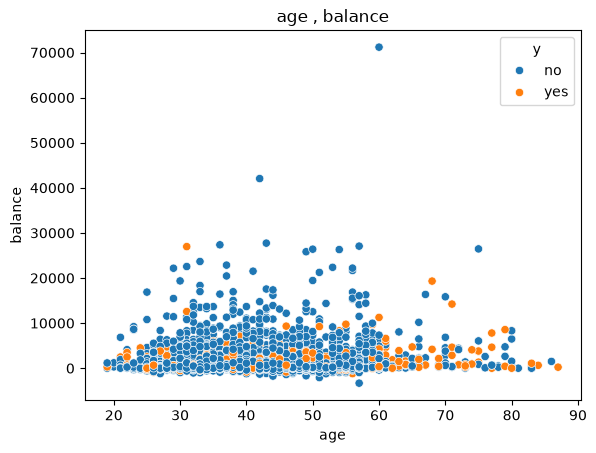

In [ ]:
plt.figure()
sns.scatterplot(data=df, x='age', y='balance', hue='y')
plt.title('age , balance')
plt.show()



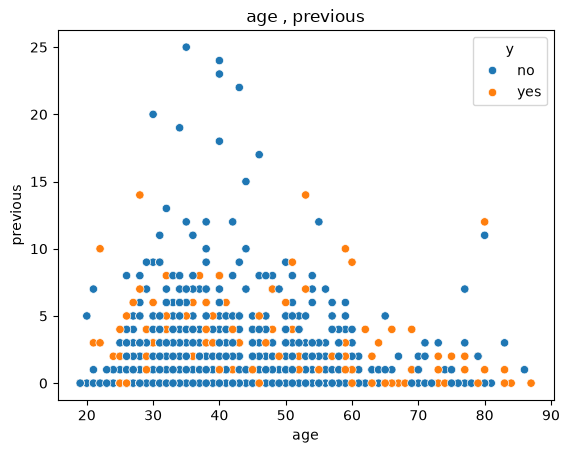

In [ ]:
plt.figure()
sns.scatterplot(data=df, x='age', y='previous', hue='y')
plt.title('age , previous')
plt.show()

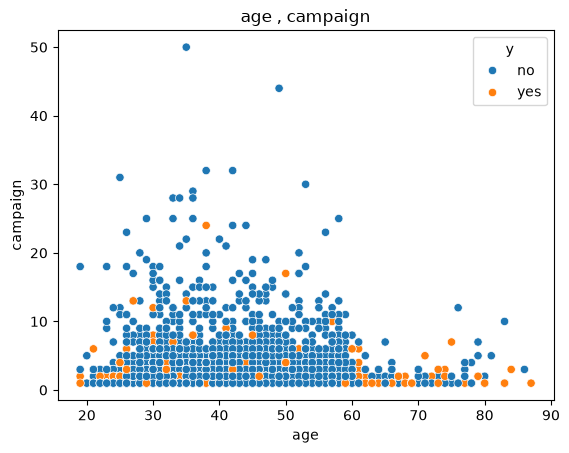

In [ ]:
plt.figure()
sns.scatterplot(data=df, x='age', y='campaign', hue='y')
plt.title('age , campaign')
plt.show()

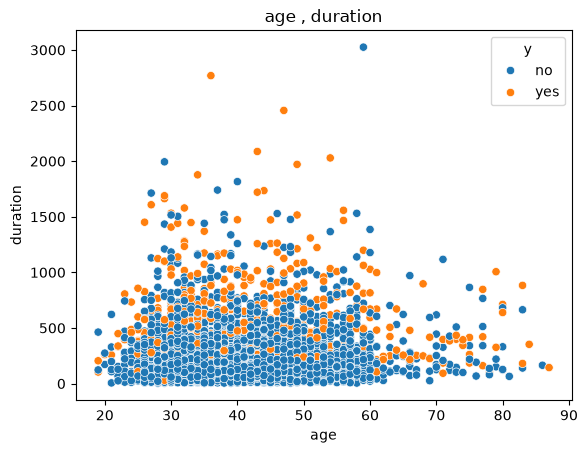

In [ ]:
plt.figure()
sns.scatterplot(data=df, x='age', y='duration', hue='y')
plt.title('age , duration')
plt.show()

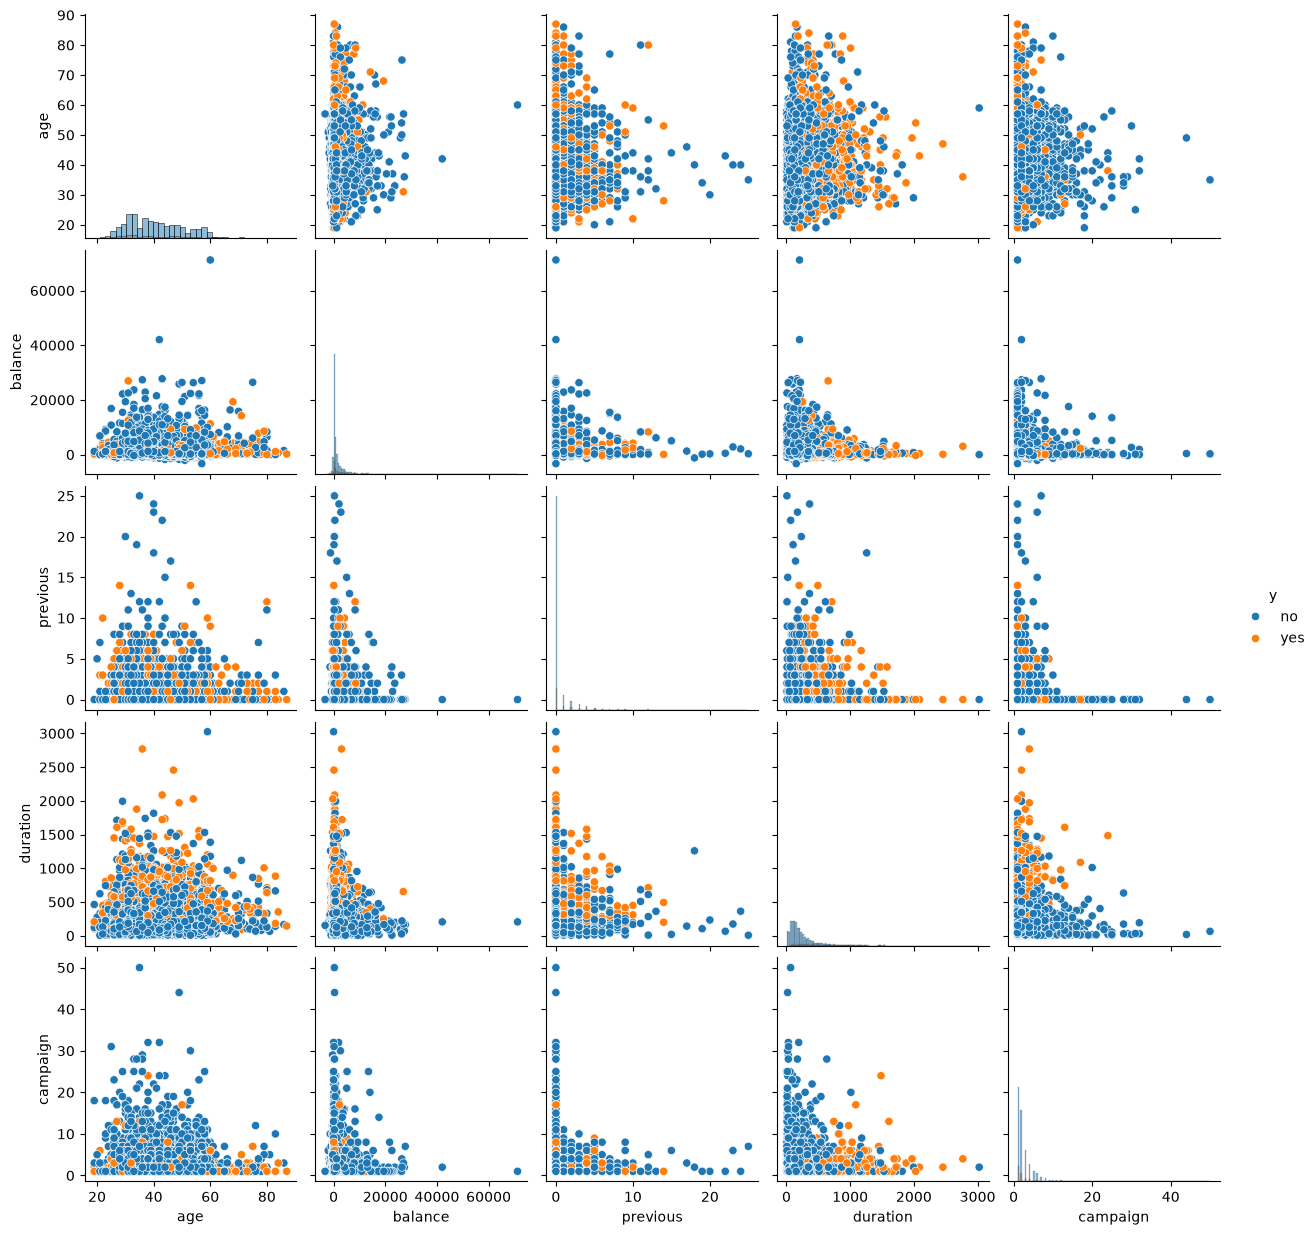

In [ ]:
sns.pairplot(
    data=df[['age', 'balance', 'previous', 'duration', 'campaign', 'y']],
    hue='y',
    diag_kind='hist'
)

plt.show()


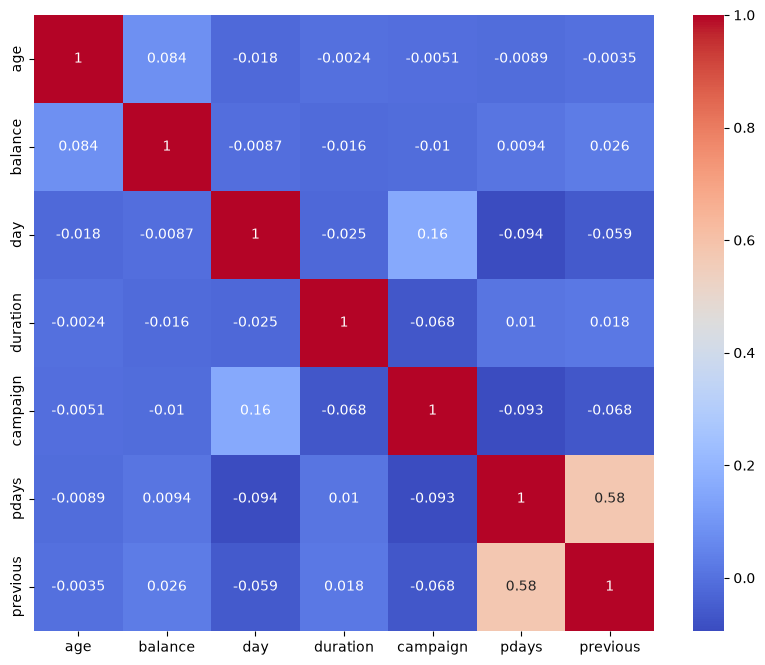

In [ ]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()